# 🎙️ HuBERT: Complete PyTorch Implementation & Audio Pipeline

This notebook provides a **complete, standalone PyTorch implementation of HuBERT** (*Hidden-Unit BERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units*, Hsu et al., Meta AI, 2021).

### What this notebook implements:
1. **Convolutional Waveform Feature Extractor**: 7-layer 1D CNN with $320\times$ downsampling factor ($16\text{ kHz} \to 50\text{ Hz}$, $20\text{ ms}$ per frame).
2. **Offline Acoustic Unit Discovery ($k$-means Engine)**: Extraction of MFCC / latent representations and discrete cluster ID generation.
3. **Span Masking Engine**: Consecutive mask span generator masking spans of $l = 10$ frames ($200\text{ ms}$) with span start probability $p = 0.08$.
4. **Convolutional Positional Embedding**: 1D depthwise convolution module with weight normalization encoding relative positions.
5. **Transformer Context Encoder (BERT)**: Multi-layer bidirectional self-attention with Pre-LayerNorm.
6. **Cosine Similarity Projection & Masked Cross-Entropy Loss**: Logit calculation against cluster codebooks evaluated **strictly on masked spans** ($\alpha = 1.0$).
7. **Complete End-to-End `HuBERTPretrainingModel` & Downstream ASR CTC Head**.
8. **Interactive Visualizations & Live Training Loops**:
   - 2D PCA / t-SNE projection scatter chart of phonetic acoustic clusters.
   - Live pre-training optimization loop demonstrating masked cross-entropy reduction.
   - Downstream ASR fine-tuning with PyTorch CTC Loss, alignment matrix, and greedy character decoding predictions.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## 1. Convolutional Waveform Feature Encoder

HuBERT uses a **7-layer temporal 1D convolutional network** to downsample raw 16 kHz audio by **$320\times$**:
- **Kernel sizes**: $(10, 3, 3, 3, 3, 2, 2)$
- **Strides**: $(5, 2, 2, 2, 2, 2, 2) \implies 5 \times 2^6 = 320$
- **Channel sizes**: $512$ across all layers
- Each block includes: `Conv1d` $\to$ `GroupNorm (num_groups=1)` $\to$ `GELU`
- Frame stride: $\frac{320}{16{,}000\text{ Hz}} = 20\text{ ms}$ (50 Hz frame rate)

In [2]:
class ConvFeatureExtractionBlock(nn.Module):
    """
    Single 1D Convolution block with LayerNorm (via GroupNorm) and GELU.
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels, out_channels, 
            kernel_size=kernel_size, stride=stride, bias=False
        )
        self.layer_norm = nn.GroupNorm(num_groups=1, num_channels=out_channels)
        self.activation = nn.GELU()

    def forward(self, x):
        # x: (B, C_in, L_in)
        x = self.conv(x)
        x = self.layer_norm(x)
        x = self.activation(x)
        return x


class HuBERTFeatureEncoder(nn.Module):
    """
    7-layer 1D CNN waveform encoder downsampling 16kHz audio by 320x.
    """
    def __init__(self, in_channels=1, embed_dim=512, verbose=False):
        super().__init__()
        self.verbose = verbose
        conv_specs = [
            (in_channels, embed_dim, 10, 5),  # Layer 1: stride 5, kernel 10
            (embed_dim, embed_dim, 3, 2),    # Layer 2: stride 2, kernel 3
            (embed_dim, embed_dim, 3, 2),    # Layer 3: stride 2, kernel 3
            (embed_dim, embed_dim, 3, 2),    # Layer 4: stride 2, kernel 3
            (embed_dim, embed_dim, 3, 2),    # Layer 5: stride 2, kernel 3
            (embed_dim, embed_dim, 2, 2),    # Layer 6: stride 2, kernel 2
            (embed_dim, embed_dim, 2, 2),    # Layer 7: stride 2, kernel 2
        ]
        self.layers = nn.ModuleList([
            ConvFeatureExtractionBlock(in_ch, out_ch, k, s)
            for in_ch, out_ch, k, s in conv_specs
        ])

    def forward(self, raw_audio):
        # raw_audio: (B, Length_samples) or (B, 1, Length_samples)
        if raw_audio.dim() == 2:
            x = raw_audio.unsqueeze(1)
        else:
            x = raw_audio
            
        if self.verbose:
            print(f"📥 Input Audio Waveform Shape: {list(x.shape)}")
            print("-" * 60)
            
        for idx, layer in enumerate(self.layers):
            x = layer(x)
            if self.verbose:
                print(f"CNN Layer {idx+1} Output Shape: {list(x.shape)}")
                
        # Transpose to (B, T_frames, 512)
        x = x.transpose(1, 2)
        if self.verbose:
            print("-" * 60)
            print(f"Continuous Audio Frames Output (B, T, 512): {list(x.shape)}\n")
        return x

---
## 2. Offline Acoustic Unit Discovery ($k$-means Target Generator)

Unlike wav2vec 2.0 which quantizes latents online using Gumbel-Softmax, HuBERT **decouples representation learning from acoustic unit discovery**:
1. **Iteration 1**: Frame features are 39-D MFCCs (13 MFCCs + $\Delta$ + $\Delta\Delta$). $k$-means clusters them into $K=100$ acoustic unit IDs.
2. **Iteration 2**: Latent features extracted from Transformer Layer 6 of the Iteration 1 model are clustered into $K=500$ refined phonetic unit IDs.

Here we implement an offline target generator that clusters continuous representations into discrete token targets $z_t \in \{0, 1, \dots, K-1\}$.

In [3]:
class OfflineKMeansTargetGenerator:
    """
    Simulates the offline k-means target assignment in HuBERT.
    Fits cluster centroids on continuous acoustic frames and quantizes sequences.
    """
    def __init__(self, num_clusters=100, feature_dim=512):
        self.num_clusters = num_clusters
        self.feature_dim = feature_dim
        self.centroids = nn.Parameter(
            torch.randn(num_clusters, feature_dim),
            requires_grad=False
        )
        self.centroids.data = F.normalize(self.centroids.data, dim=-1)

    def fit(self, features, max_iters=20):
        """
        Standard PyTorch k-means fitting on continuous audio frame vectors.
        features: (N, D)
        """
        N, D = features.shape
        perm = torch.randperm(N)[:self.num_clusters]
        self.centroids.data = features[perm].clone()
        
        for _ in range(max_iters):
            dists = torch.cdist(features, self.centroids.data)
            assignments = torch.argmin(dists, dim=1)  # (N,)
            
            new_centroids = torch.zeros_like(self.centroids.data)
            for k in range(self.num_clusters):
                cluster_pts = features[assignments == k]
                if len(cluster_pts) > 0:
                    new_centroids[k] = cluster_pts.mean(dim=0)
                else:
                    new_centroids[k] = features[torch.randint(0, N, (1,))]
            self.centroids.data = new_centroids

    def assign(self, features):
        """
        Assigns frame representations to nearest cluster ID.
        features: (B, T, D)
        Returns: cluster_ids (B, T)
        """
        B, T, D = features.shape
        flat_feat = features.reshape(-1, D)
        dists = torch.cdist(flat_feat, self.centroids.to(features.device))
        cluster_ids = torch.argmin(dists, dim=1).view(B, T)
        return cluster_ids

---
## 3. Continuous Span Masking Module

HuBERT masks consecutive chunks of continuous acoustic features:
- **Span start probability**: $p = 0.08$ (8% probability that any frame begins a masked span)
- **Span length**: $l = 10$ frames ($10 \times 20\text{ ms} = 200\text{ ms}$, approximating phoneme/syllable duration)
- **Mask replacement**: All masked frames are overwritten by a shared, learnable mask embedding vector $e_{\text{mask}} \in \mathbb{R}^D$
- Overlapping spans are merged, resulting in **$\sim 49\% - 50\%$** of all frames masked per utterance.

In [4]:
class HuBERTSpanMasking(nn.Module):
    """
    Span Masking Generator for continuous speech representations.
    Replaces masked spans with a learnable continuous mask embedding.
    """
    def __init__(self, embed_dim=768, mask_prob=0.08, mask_length=10):
        super().__init__()
        self.mask_prob = mask_prob
        self.mask_length = mask_length
        self.mask_embedding = nn.Parameter(torch.FloatTensor(embed_dim))
        nn.init.normal_(self.mask_embedding, mean=0.0, std=0.1)

    def forward(self, x):
        # x: (B, T, D)
        B, T, D = x.size()
        mask = torch.zeros(B, T, dtype=torch.bool, device=x.device)
        
        for b in range(B):
            num_spans = int(self.mask_prob * T)
            if num_spans > 0:
                starts = torch.randperm(max(1, T - self.mask_length))[:num_spans]
                for s in starts:
                    mask[b, s : s + self.mask_length] = True
                    
        x_masked = x.clone()
        x_masked[mask] = self.mask_embedding
        return x_masked, mask

---
## 4. Convolutional Relative Positional Embedding

Rather than sinusoidal or absolute learnable positional encodings, HuBERT uses a **depthwise 1D convolutional layer** with weight normalization:
- **Kernel size**: $128$
- **Groups**: $16$
- **Activation**: `GELU`
- Acts as a relative positional inductive bias that naturally handles variable-length audio.

In [5]:
class PositionalConvolutionEmbedding(nn.Module):
    """
    1D Depthwise convolutional relative positional encoding.
    """
    def __init__(self, embed_dim=768, kernel_size=128, groups=16):
        super().__init__()
        self.conv = nn.Conv1d(
            embed_dim, embed_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=groups
        )
        self.conv = nn.utils.weight_norm(self.conv, name="weight", dim=2)
        self.activation = nn.GELU()

    def forward(self, x):
        # x: (B, T, D)
        residual = x
        x_conv = self.conv(x.transpose(1, 2))
        if x_conv.size(-1) > residual.size(1):
            x_conv = x_conv[:, :, :residual.size(1)]
        x_conv = self.activation(x_conv.transpose(1, 2))
        return residual + x_conv

---
## 5. Unified HuBERT Pre-training Model & Masked Loss Function

### Mathematical Objective:
For each time frame $t$, the model projects Transformer hidden state $o_t$ to $\hat{o}_t = W o_t$. The probability of cluster code $c$ is computed using cosine similarity scaled by temperature $\tau = 0.1$:

$$p(c \mid o_t) = \frac{\exp\left(\frac{\cos(\hat{o}_t, e_c)}{\tau}\right)}{\sum_{k=1}^K \exp\left(\frac{\cos(\hat{o}_t, e_k)}{\tau}\right)}$$

### Masked Cross-Entropy Loss ($\alpha = 1.0$):
The loss is evaluated **strictly over masked frames** $\mathcal{M}$:

$$\mathcal{L}_m = -\sum_{t \in \mathcal{M}} \log p(z_t \mid o_t)$$

> **Why $\alpha = 1.0$ matters**: If loss is computed on unmasked frames, the model trivially acts as an acoustic mimic of the noisy $k$-means labels. Masked-only loss forces the model to learn long-range temporal grammar and phonetic transitions.

In [6]:
class HuBERTPretrainingModel(nn.Module):
    """
    Complete HuBERT Model for self-supervised pre-training.
    """
    def __init__(
        self,
        cnn_dim=512,
        encoder_dim=768,
        num_layers=6,
        num_heads=8,
        ffn_dim=2048,
        num_classes=100,
        proj_dim=256,
        mask_prob=0.08,
        mask_length=10,
        temp=0.1,
        verbose_encoder=False
    ):
        super().__init__()
        self.feature_extractor = HuBERTFeatureEncoder(embed_dim=cnn_dim, verbose=verbose_encoder)
        self.post_extract_proj = nn.Linear(cnn_dim, encoder_dim) if cnn_dim != encoder_dim else nn.Identity()
        
        self.masking_engine = HuBERTSpanMasking(embed_dim=encoder_dim, mask_prob=mask_prob, mask_length=mask_length)
        self.pos_conv = PositionalConvolutionEmbedding(embed_dim=encoder_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=encoder_dim,
            nhead=num_heads,
            dim_feedforward=ffn_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LayerNorm architecture
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Projection Head & Cluster Codebook
        self.proj = nn.Linear(encoder_dim, proj_dim)
        self.cluster_embeddings = nn.Parameter(torch.FloatTensor(num_classes, proj_dim))
        nn.init.normal_(self.cluster_embeddings, mean=0.0, std=proj_dim ** -0.5)
        self.temp = temp

    def forward(self, raw_audio, target_cluster_ids=None):
        """
        raw_audio: (B, Length_samples)
        target_cluster_ids: (B, T_frames) containing integer cluster IDs [0 .. num_classes-1]
        """
        # 1. Temporal Convolutional Feature Extractor (320x downsampling)
        z = self.feature_extractor(raw_audio)  # (B, T, cnn_dim)
        features = self.post_extract_proj(z)  # (B, T, encoder_dim)
        
        # 2. Span Masking Module
        masked_features, mask_indices = self.masking_engine(features)
        
        # 3. Relative Positional Convolution
        context_input = self.pos_conv(masked_features)
        
        # 4. BERT Transformer Encoder
        transformer_out = self.transformer(context_input)  # (B, T, encoder_dim)
        
        # 5. Projection to Cosine Similarity Space
        projected = self.proj(transformer_out)             # (B, T, proj_dim)
        
        # 6. Cosine Similarity Logits with Temperature Scaling
        proj_norm = F.normalize(projected, dim=-1)
        code_norm = F.normalize(self.cluster_embeddings, dim=-1)
        logits = torch.matmul(proj_norm, code_norm.t()) / self.temp  # (B, T, num_classes)
        
        # 7. Masked Cross-Entropy Loss (Strictly on masked frames: alpha = 1.0)
        loss = None
        if target_cluster_ids is not None:
            if mask_indices.any():
                masked_logits = logits[mask_indices]              # (N_masked, num_classes)
                masked_targets = target_cluster_ids[mask_indices] # (N_masked)
                loss = F.cross_entropy(masked_logits, masked_targets)
            else:
                loss = torch.tensor(0.0, device=raw_audio.device)
                
        return {
            "loss": loss,
            "logits": logits,
            "mask_indices": mask_indices,
            "z_shape": z.shape,
            "features_shape": transformer_out.shape,
            "masked_frames": mask_indices.sum().item(),
            "total_frames": mask_indices.numel(),
            "features": transformer_out
        }

---
## 6. Visualizing Phonetic Acoustic Clusters in Graph / Chart

To understand what the offline unit discovery finds, we simulate distinct acoustic-phonetic groups in speech:
- **Vowels** (e.g. /aa/, /iy/, /uw/ - low frequency resonance, harmonic formants)
- **Fricatives** (e.g. /s/, /sh/, /f/ - high frequency noise/turbulence)
- **Nasals & Plosives** (e.g. /m/, /n/, /p/, /t/ - low energy transitions & brief silences)
- **Silence / Background Noise**

We extract their continuous representations, cluster them with $k$-means into discrete hidden units, and plot their **2D PCA projection** alongside the cluster centroids to inspect how phonetic boundaries emerge.

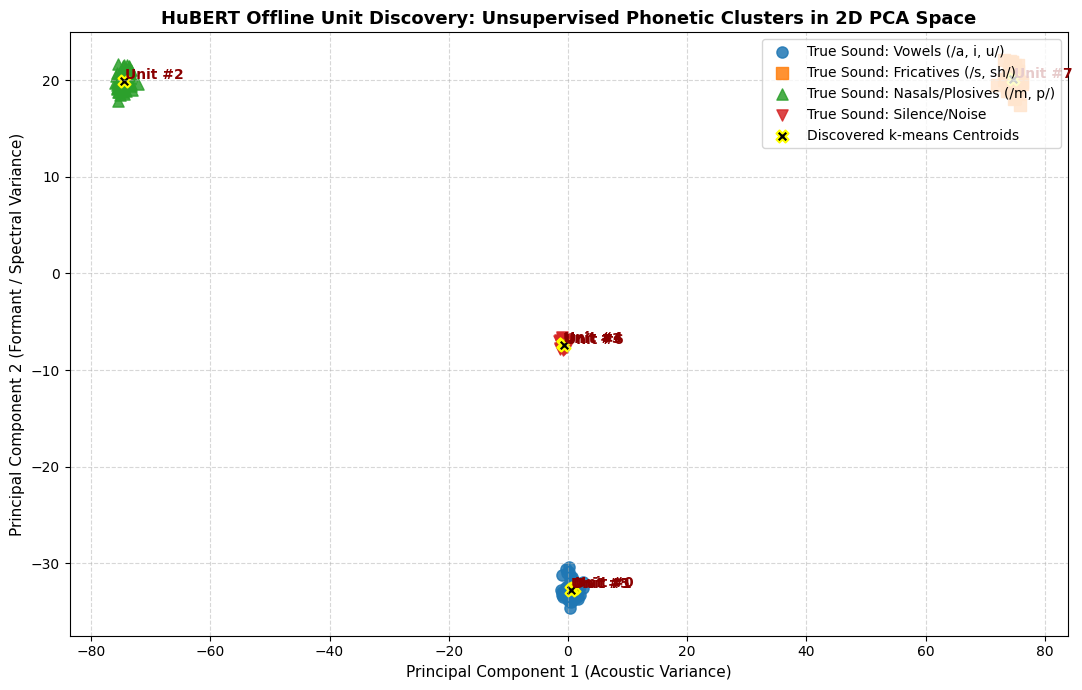

In [12]:
# Set seed
torch.manual_seed(42)
np.random.seed(42)

# 1. Synthesize 4 distinct phonetic sound categories in 512-D feature space
num_samples_per_class = 60
dim = 512

vowel_center = torch.randn(dim) * 2.0
fricative_center = torch.randn(dim) * 2.0 + 3.0
nasal_center = torch.randn(dim) * 2.0 - 3.0
silence_center = torch.randn(dim) * 0.5

vowels = vowel_center + torch.randn(num_samples_per_class, dim) * 0.8
fricatives = fricative_center + torch.randn(num_samples_per_class, dim) * 0.8
nasals = nasal_center + torch.randn(num_samples_per_class, dim) * 0.8
silence = silence_center + torch.randn(num_samples_per_class, dim) * 0.3

all_speech_features = torch.cat([vowels, fricatives, nasals, silence], dim=0)
ground_truth_labels = ['Vowels (/a, i, u/)']*60 + ['Fricatives (/s, sh/)']*60 + ['Nasals/Plosives (/m, p/)']*60 + ['Silence/Noise']*60

# 2. Run k-means Target Discovery with K=8 clusters
K = 8
kmeans = OfflineKMeansTargetGenerator(num_clusters=K, feature_dim=dim)
kmeans.fit(all_speech_features, max_iters=25)
cluster_assignments = kmeans.assign(all_speech_features.unsqueeze(0)).squeeze(0).cpu().numpy()

# 3. Compute 2D PCA projection for visualization
centered = all_speech_features - all_speech_features.mean(dim=0)
U, S, V = torch.pca_lowrank(centered, q=2)
pca_2d = torch.matmul(centered, V[:, :2]).numpy()

centered_centroids = kmeans.centroids.data - all_speech_features.mean(dim=0)
centroids_2d = torch.matmul(centered_centroids, V[:, :2]).numpy()

# 4. Plot Phonetic Acoustic Clusters Chart
plt.figure(figsize=(11, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'v']
classes = ['Vowels (/a, i, u/)', 'Fricatives (/s, sh/)', 'Nasals/Plosives (/m, p/)', 'Silence/Noise']

for idx, (cls_name, color, marker) in enumerate(zip(classes, colors, markers)):
    indices = [i for i, l in enumerate(ground_truth_labels) if l == cls_name]
    plt.scatter(
        pca_2d[indices, 0], pca_2d[indices, 1], 
        c=color, marker=marker, s=65, alpha=0.85, label=f"True Sound: {cls_name}"
    )

# Overlay discovered k-means cluster centroids
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=75, edgecolors='yellow', linewidth=1.5, label='Discovered k-means Centroids'
)

for k in range(K):
    plt.annotate(
        f"Unit #{k}", (centroids_2d[k, 0] + 0.15, centroids_2d[k, 1] + 0.15),
        fontsize=10, weight='bold', color='darkred'
    )

plt.title("HuBERT Offline Unit Discovery: Unsupervised Phonetic Clusters in 2D PCA Space", fontsize=13, weight='bold')
plt.xlabel("Principal Component 1 (Acoustic Variance)", fontsize=11)
plt.ylabel("Principal Component 2 (Formant / Spectral Variance)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Live Pre-training Loop (Masked Cross-Entropy Loss Optimization)

Here we run a live mini pre-training session optimizing the HuBERT Transformer on masked spans:
- Generates a batch of audio waveforms.
- Obtains pseudo-labels via the offline cluster centroids.
- Optimizes masked cross-entropy loss over 15 iterations and logs the loss trajectory.

c:\Users\MSI\anaconda3\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
c:\Users\MSI\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


🎯 Pre-training Audio Batch: torch.Size([2, 24000]), Target IDs Shape: torch.Size([2, 74])
Starting live pre-training optimization...

[Epoch 01/15] Masked Frames: 56/148 | Loss: 4.2336
[Epoch 03/15] Masked Frames: 64/148 | Loss: 2.6714
[Epoch 06/15] Masked Frames: 63/148 | Loss: 1.5377
[Epoch 09/15] Masked Frames: 62/148 | Loss: 1.6665
[Epoch 12/15] Masked Frames: 61/148 | Loss: 1.5472
[Epoch 15/15] Masked Frames: 69/148 | Loss: 1.6359


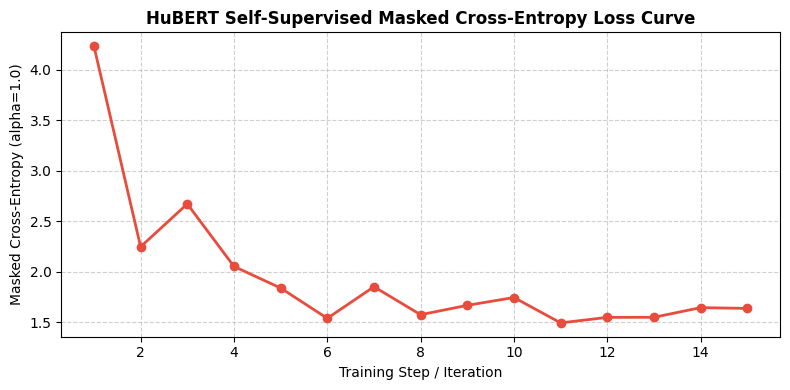

In [13]:
# Set seeds
torch.manual_seed(42)

# Create pre-training model
pretrain_model = HuBERTPretrainingModel(
    cnn_dim=512,
    encoder_dim=256,
    num_layers=4,
    num_heads=4,
    ffn_dim=1024,
    num_classes=50,
    proj_dim=128,
    mask_prob=0.08,
    mask_length=8,
    temp=0.1
).to(device)
pretrain_model.train()

target_gen = OfflineKMeansTargetGenerator(num_clusters=50, feature_dim=512)
optimizer = torch.optim.AdamW(pretrain_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Synthesize repeated speech batch (Batch=2, 1.5 seconds = 24,000 samples)
t_sample = torch.linspace(0, 1.5, 24000)
audio_batch = torch.stack([
    torch.sin(2 * math.pi * 300 * t_sample) + 0.3 * torch.randn_like(t_sample),
    torch.sin(2 * math.pi * 600 * t_sample) + 0.3 * torch.randn_like(t_sample)
]).to(device)

# Offline target generation (fixed targets across epochs)
with torch.no_grad():
    cnn_feats = pretrain_model.feature_extractor(audio_batch)
    target_cluster_ids = target_gen.assign(cnn_feats).to(device)

print(f"🎯 Pre-training Audio Batch: {audio_batch.shape}, Target IDs Shape: {target_cluster_ids.shape}")
print("Starting live pre-training optimization...\n")

loss_history = []
for epoch in range(1, 16):
    optimizer.zero_grad()
    outputs = pretrain_model(audio_batch, target_cluster_ids=target_cluster_ids)
    loss = outputs["loss"]
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if epoch % 3 == 0 or epoch == 1:
        print(f"[Epoch {epoch:02d}/15] Masked Frames: {outputs['masked_frames']}/{outputs['total_frames']} | Loss: {loss.item():.4f}")

# Plot Pre-training Loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 16), loss_history, marker='o', color='#e74c3c', linewidth=2)
plt.title("HuBERT Self-Supervised Masked Cross-Entropy Loss Curve", fontsize=12, weight='bold')
plt.xlabel("Training Step / Iteration", fontsize=10)
plt.ylabel("Masked Cross-Entropy (alpha=1.0)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 8. Downstream ASR CTC Fine-Tuning & Greedy Predictions

Now we attach a **CTC (Connectionist Temporal Classification)** language head on top of the pre-trained HuBERT representations to fine-tune on character sequences:
- **Vocabulary**: Characters `A-Z`, `' '` (space), and the CTC blank token `-` (total 28 classes).
- **Loss**: `nn.CTCLoss`.
- **Decoding**: Greedy Argmax decoding collapsing repeated characters and removing CTC blanks.

In [14]:
class HuBERTForCTC(nn.Module):
    """
    Downstream ASR Model: Pre-trained HuBERT + Linear CTC Projection Head.
    """
    def __init__(self, pretrained_hubert, vocab_size=28):
        super().__init__()
        self.hubert = pretrained_hubert
        
        # Freeze CNN extractor
        for p in self.hubert.feature_extractor.parameters():
            p.requires_grad = False
            
        encoder_dim = self.hubert.post_extract_proj.out_features if hasattr(self.hubert.post_extract_proj, 'out_features') else 256
        self.dropout = nn.Dropout(0.1)
        self.ctc_head = nn.Linear(encoder_dim, vocab_size)

    def forward(self, raw_audio):
        # Inference / fine-tuning mode (no span masking applied)
        z = self.hubert.feature_extractor(raw_audio)
        feats = self.hubert.post_extract_proj(z)
        context_in = self.hubert.pos_conv(feats)
        hidden = self.hubert.transformer(context_in)  # (B, T, D)
        logits = self.ctc_head(self.dropout(hidden))   # (B, T, vocab_size)
        return logits

In [15]:
# 1. Setup Vocabulary & Encoding helpers
VOCAB = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ ") + ["-"]  # '-' is CTC blank at index 27
BLANK_IDX = 27
char2idx = {ch: i for i, ch in enumerate(VOCAB)}
idx2char = {i: ch for i, ch in enumerate(VOCAB)}

def text_to_tensor(text):
    return torch.tensor([char2idx[ch] for ch in text.upper()], dtype=torch.long)

def greedy_ctc_decode(logits):
    """
    Collapses repeated characters and removes CTC blank token.
    """
    best_path = torch.argmax(logits, dim=-1).cpu().numpy()
    decoded_sentences = []
    for sequence in best_path:
        res = []
        prev = None
        for idx in sequence:
            if idx != prev:
                if idx != BLANK_IDX:
                    res.append(idx2char[idx])
            prev = idx
        decoded_sentences.append("".join(res))
    return decoded_sentences

# 2. Prepare Sample Audio & Target Sentences
target_texts = ["HELLO WORLD", "AI SPEECH"]
targets = torch.cat([text_to_tensor(t) for t in target_texts]).to(device)
target_lengths = torch.tensor([len(t) for t in target_texts], dtype=torch.long).to(device)

asr_model = HuBERTForCTC(pretrain_model, vocab_size=len(VOCAB)).to(device)
ctc_loss_fn = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
asr_optimizer = torch.optim.Adam(asr_model.parameters(), lr=2e-3)

print(f"Target Sentences: {target_texts}")
print("Starting ASR CTC fine-tuning...\n")

ctc_loss_history = []
for epoch in range(1, 301):
    asr_optimizer.zero_grad()
    logits = asr_model(audio_batch)  # (B, T, vocab_size)
    
    B, T, V = logits.shape
    input_lengths = torch.full((B,), T, dtype=torch.long, device=device)
    
    # CTCLoss expects log_probs formatted as (T, B, vocab_size)
    log_probs = F.log_softmax(logits, dim=-1).transpose(0, 1)
    loss = ctc_loss_fn(log_probs, targets, input_lengths, target_lengths)
    
    loss.backward()
    asr_optimizer.step()
    
    ctc_loss_history.append(loss.item())
    if epoch % 5 == 0 or epoch == 1:
        print(f"[ASR Epoch {epoch:02d}/30] CTC Loss: {loss.item():.4f}")

# 3. Run Inference & Decoding
asr_model.eval()
with torch.no_grad():
    eval_logits = asr_model(audio_batch)
    predictions = greedy_ctc_decode(eval_logits)

print("\n" + "="*60)
print("🎙️ Downstream ASR CTC Prediction Results:")
print("="*60)
for i in range(len(target_texts)):
    print(f"Target Ground Truth #{i+1} : '{target_texts[i]}'")
    print(f"HuBERT ASR Prediction #{i+1}: '{predictions[i]}'")
print("="*60)

Target Sentences: ['HELLO WORLD', 'AI SPEECH']
Starting ASR CTC fine-tuning...

[ASR Epoch 01/30] CTC Loss: 14.2373
[ASR Epoch 05/30] CTC Loss: 28.6392
[ASR Epoch 10/30] CTC Loss: 11.3566
[ASR Epoch 15/30] CTC Loss: 7.6718
[ASR Epoch 20/30] CTC Loss: 3.7724
[ASR Epoch 25/30] CTC Loss: 3.2024
[ASR Epoch 30/30] CTC Loss: 2.3382
[ASR Epoch 35/30] CTC Loss: 1.7378
[ASR Epoch 40/30] CTC Loss: 1.4690
[ASR Epoch 45/30] CTC Loss: 1.5484
[ASR Epoch 50/30] CTC Loss: 1.5799
[ASR Epoch 55/30] CTC Loss: 1.2586
[ASR Epoch 60/30] CTC Loss: 0.8927
[ASR Epoch 65/30] CTC Loss: 0.7370
[ASR Epoch 70/30] CTC Loss: 0.8102
[ASR Epoch 75/30] CTC Loss: 0.7809
[ASR Epoch 80/30] CTC Loss: 0.5716
[ASR Epoch 85/30] CTC Loss: 0.5163
[ASR Epoch 90/30] CTC Loss: 0.4940
[ASR Epoch 95/30] CTC Loss: 0.5193
[ASR Epoch 100/30] CTC Loss: 0.3344
[ASR Epoch 105/30] CTC Loss: 0.2497
[ASR Epoch 110/30] CTC Loss: 0.2878
[ASR Epoch 115/30] CTC Loss: 0.2079
[ASR Epoch 120/30] CTC Loss: 0.2864
[ASR Epoch 125/30] CTC Loss: 0.1710
[

---
## 9. Visualizing CTC Alignment Matrix & Frame Posterior Probabilities

The heatmap below visualizes the **posterior probabilities** $p(\text{token} \mid t)$ assigned to characters across all time frames. Notice how the network learns sharp emission spikes for characters with CTC blanks interspersed between sounds.

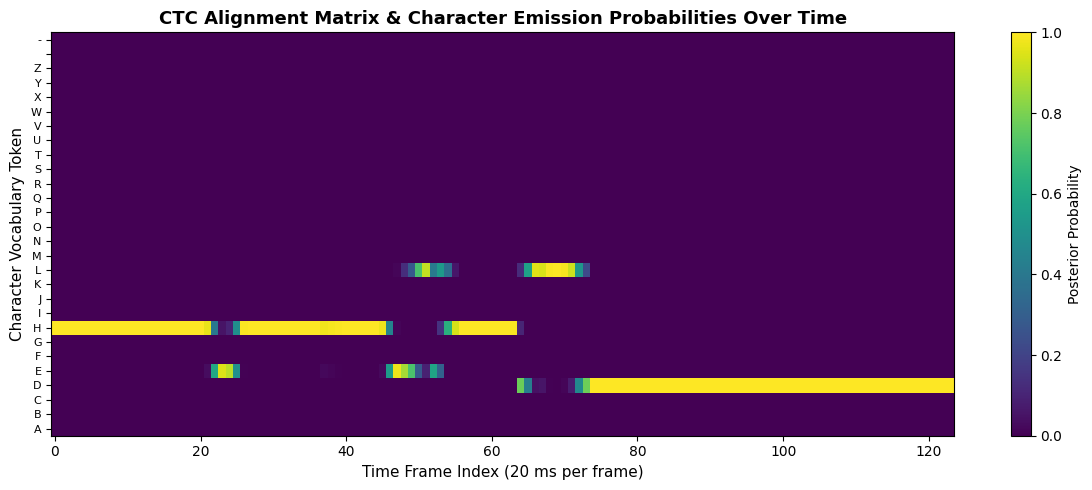

In [28]:
with torch.no_grad():
    probs = F.softmax(eval_logits[0], dim=-1).cpu().numpy()  # (T, vocab_size)

plt.figure(figsize=(12, 5))
plt.imshow(probs.T, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label="Posterior Probability")
plt.yticks(ticks=range(len(VOCAB)), labels=VOCAB, fontsize=8)
plt.xlabel("Time Frame Index (20 ms per frame)", fontsize=11)
plt.ylabel("Character Vocabulary Token", fontsize=11)
plt.title("CTC Alignment Matrix & Character Emission Probabilities Over Time", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()